In [ ]:
import urllib.request
import numpy as np
import pandas as pd

# ==========================================
# FUNDAMENTAL INVARIANTS WILL RG
# ==========================================
a_k = 7.02e-11              # Machian scale (m/s^2)
kpc_to_m = 3.08567758e19    # Parsecs to meters conversion

# ==========================================
# SPARC PARAMETERS (Mass-to-Light)
# ==========================================
# According to SPARC abstract Y_disk = 0.5, but can reach 0.7 for bright galaxies
Y_disk = 0.5
Y_bulge = 0.7

def calculate_will_radii():
    url = "https://raw.githubusercontent.com/AntonRize/WILL/b40735946200c06b4e69da48955b754ada64e38b/SPARC%20DATA/table2.dat"

    print("Fetching SPARC database...")
    req = urllib.request.Request(url)
    with urllib.request.urlopen(req) as response:
        lines = response.read().decode('utf-8').splitlines()

    data = []

    for line in lines:
        if line.startswith('#') or len(line) < 70:
            continue

        name = line[0:11].strip()

        # Parsing byte structure from table2.dat
        try:
            rad_sparc_kpc = float(line[19:25])
            v_obs = float(line[26:32])
            v_gas = float(line[39:45])
            v_disk = float(line[46:52])
            v_bulge = float(line[53:59])
        except ValueError:
            continue

        # Calculate square of baryonic velocity (in km/s)^2
        # Gas can have negative contribution in inner regions
        v_gas_sq = v_gas * abs(v_gas)
        v_bar_sq_kms = v_gas_sq + Y_disk * (v_disk**2) + Y_bulge * (v_bulge**2)

        # Ignore points where baryonic mass becomes negative or V_bar > V_obs
        if v_bar_sq_kms <= 0 or (v_obs**2) <= v_bar_sq_kms:
            continue

        # Convert to SI (m/s)
        v_obs_ms = v_obs * 1000
        v_bar_sq_ms = v_bar_sq_kms * 1e6

        # ----------------------------------------------------
        # GALACTIC TOPOLOGICAL RULER EQUATION
        # ----------------------------------------------------
        # R = (V_obs^2 - V_bar^2)^2 / (V_bar^2 * a_k)

        numerator = (v_obs_ms**2 - v_bar_sq_ms)**2
        denominator = v_bar_sq_ms * a_k
        r_will_m = numerator / denominator

        # Convert back to kpc for comparison
        r_will_kpc = r_will_m / kpc_to_m

        data.append({
            'Galaxy': name,
            'R_SPARC_kpc': rad_sparc_kpc,
            'R_WILL_kpc': r_will_kpc,
            'Ratio (WILL/SPARC)': r_will_kpc / rad_sparc_kpc
        })

    df = pd.DataFrame(data)

    # Filtering extreme outliers (often due to Y_disk uncertainty)
    df_filtered = df[(df['Ratio (WILL/SPARC)'] > 0.1) & (df['Ratio (WILL/SPARC)'] < 10)]

    print("\n=== COMPARISON RESULTS ===")
    print(f"Data points processed: {len(df)}")
    print(f"Mean ratio R_WILL / R_SPARC: {df_filtered['Ratio (WILL/SPARC)'].mean():.3f}")
    print(f"Median ratio R_WILL / R_SPARC: {df_filtered['Ratio (WILL/SPARC)'].median():.3f}")

    print("\nFirst 15 data points:")
    print(df.head(15).to_string(index=False))

    return df

if __name__ == '__main__':
    df_results = calculate_will_radii()

Fetching SPARC database...

=== COMPARISON RESULTS ===
Data points processed: 3175
Mean ratio R_WILL / R_SPARC: 1.523
Median ratio R_WILL / R_SPARC: 1.073

First 15 data points:
Galaxy  R_SPARC_kpc  R_WILL_kpc  Ratio (WILL/SPARC)
  CamB         1.22    0.001820            0.001492
  CamB         1.47    0.019746            0.013432
  CamB         1.79    0.174541            0.097509
D512-2         0.96    0.574783            0.598732
D512-2         1.92    1.290762            0.672272
D512-2         2.88    2.158347            0.749426
D512-2         3.83    1.804739            0.471211
D564-8         0.51    0.023661            0.046394
D564-8         1.02    0.184063            0.180454
D564-8         1.53    0.546149            0.356960
D564-8         2.04    0.840893            0.412203
D564-8         2.56    1.350175            0.527412
D564-8         3.07    1.747138            0.569100
D631-7         0.90    0.000294            0.000326
D631-7         1.35    0.030802           

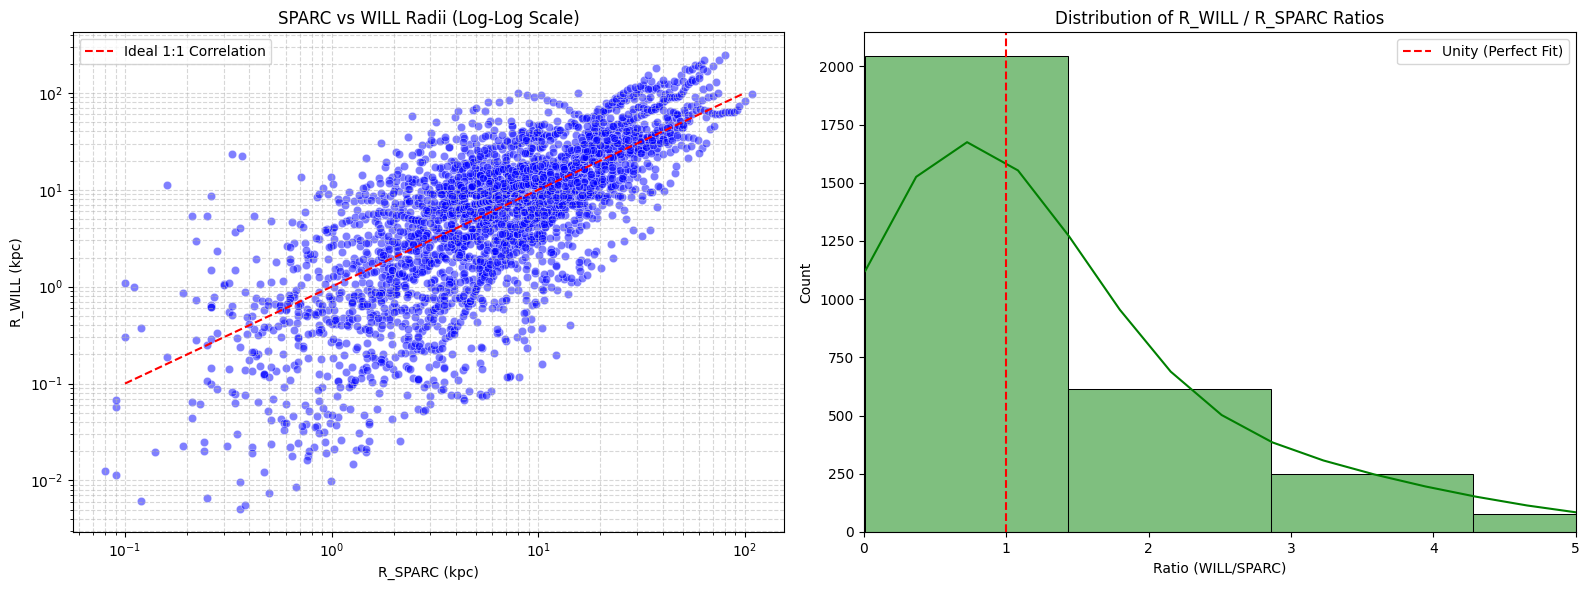

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_results(df):
    # Filter outliers for visualization
    df_plot = df[(df['Ratio (WILL/SPARC)'] > 0.01) & (df['Ratio (WILL/SPARC)'] < 100)].copy()

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Scatter Comparison
    sns.scatterplot(data=df_plot, x='R_SPARC_kpc', y='R_WILL_kpc', alpha=0.5, ax=ax[0], color='blue')
    ax[0].plot([0.1, 100], [0.1, 100], 'r--', label='Ideal 1:1 Correlation')
    ax[0].set_xscale('log')
    ax[0].set_yscale('log')
    ax[0].set_title('SPARC vs WILL Radii (Log-Log Scale)')
    ax[0].set_xlabel('R_SPARC (kpc)')
    ax[0].set_ylabel('R_WILL (kpc)')
    ax[0].legend()
    ax[0].grid(True, which="both", ls="--", alpha=0.5)

    # Plot 2: Distribution of Ratios
    sns.histplot(df_plot['Ratio (WILL/SPARC)'], bins=50, kde=True, ax=ax[1], color='green')
    ax[1].axvline(1.0, color='red', linestyle='--', label='Unity (Perfect Fit)')
    ax[1].set_xlim(0, 5)
    ax[1].set_title('Distribution of R_WILL / R_SPARC Ratios')
    ax[1].set_xlabel('Ratio (WILL/SPARC)')
    ax[1].legend()

    plt.tight_layout()
    plt.show()

plot_results(df_results)